# Analiza danych multimedialnych projekt - Klasyfikacja owoców
Andrzej Małolepszy 103777
Maciej Gońda
Patryk Kowalczyk

Dataset:
https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

## Eksploracja danych

In [179]:
path = "../fruit-and-vegetable-image-recognition"

### Liczebność klas

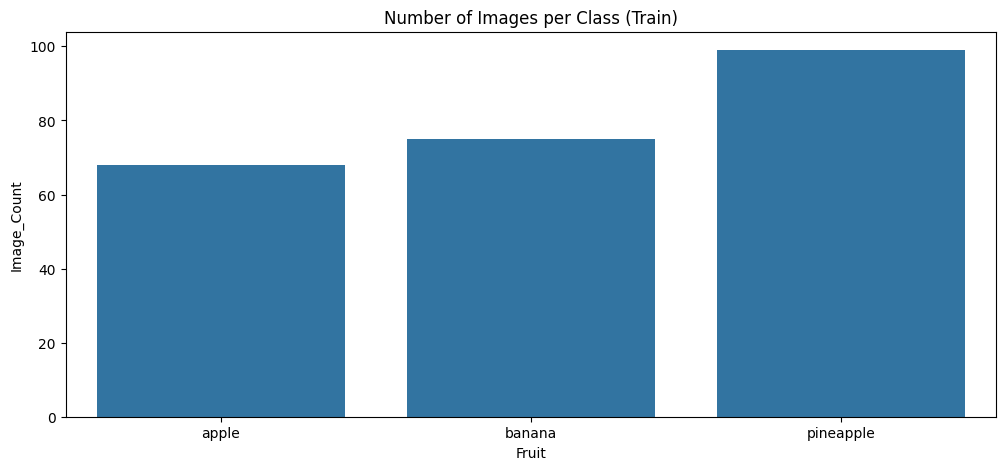

In [228]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import os

fruits = ["apple", "banana", "pineapple"]
image_count = {}

for fruit in fruits:
    fruit_path = os.path.join(path + '/train', fruit)
    image_count[fruit] = len(os.listdir(fruit_path))

df = pd.DataFrame(image_count.items(), columns=["Fruit", "Image_Count"])

plt.figure(figsize=(12,5))
seaborn.barplot(x="Fruit", y="Image_Count", data=df)
plt.title("Number of Images per Class (Train)")
plt.show()

### Przykładowy owoc

In [229]:
import cv2

def BGR2RGB(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

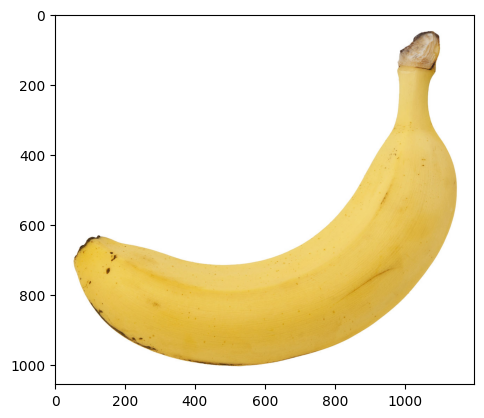

In [230]:
import matplotlib.pyplot as plt

image_path = os.path.join(path + '/train/banana/Image_3.jpg')

img = cv2.imread(image_path)
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

#### Histogram kanałów BGR

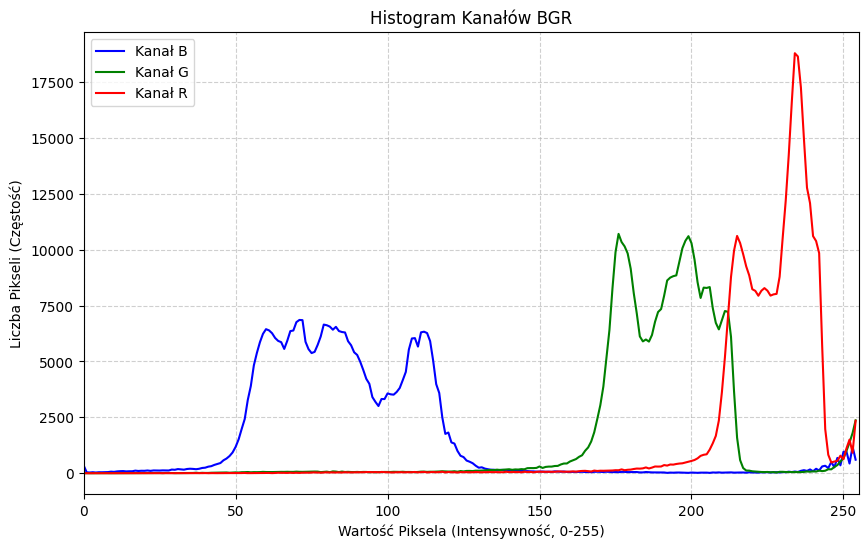

In [231]:
import cv2
import matplotlib.pyplot as plt

colors = ('b', 'g', 'r')
plt.figure(figsize=(10, 6))
plt.title('Histogram Kanałów BGR')
plt.xlabel('Wartość Piksela (Intensywność, 0-255)')
plt.ylabel('Liczba Pikseli (Częstość)')

for i, col in enumerate(colors):
  # Obliczenie histogramu dla pojedynczego kanału
  # [img]: obraz wejściowy
  # [i]: indeks kanału (0, 1 lub 2)
  # None: brak maski
  # [255]: liczba binow
  # [0, 255]: zakres wartości - bez 256, zeby wyciac bialy
  hist = cv2.calcHist([img], [i], None, [255], [0, 255])

  # Wyświetlenie histogramu
  plt.plot(hist, color=col, label=f'Kanał {col.upper()}')
  plt.xlim([0, 255])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Segmentacja

### Odszumianie - filtr medianowy
Zastępuje każdy piksel medianą wartości pikseli z jego otoczenia (5x5).
-> pozbywa sie małych niedoskonałości na owocach, jak ciemne kropki na bananie.

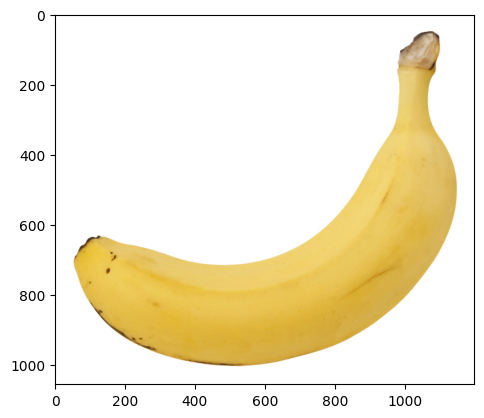

In [232]:
blurred_img = cv2.medianBlur(img, 5)
plt.imshow(BGR2RGB(blurred_img))

### konwersja dziedziny kolorów na HSV
Hue, Saturation, Value - reprezentacja kolorów niosąca więcej informacji przy przetwarzaniu ubrazów, bardziej odporna na zmianę oświetlenia (wówczas zmienia się głównie parametr V, H zostaje takie samo).

In [233]:
# konwersja na HSV
hsv_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)

#### Histogram wartości HSV

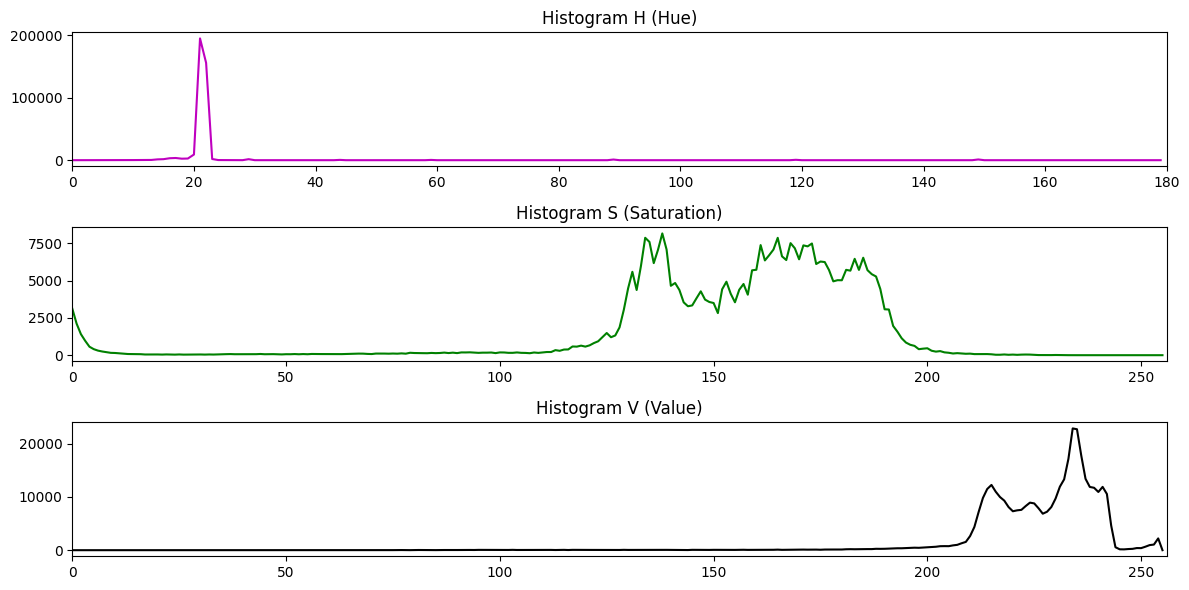

In [234]:
import cv2
import matplotlib.pyplot as plt

# Rozdzielenie kanałów
h, s, v = cv2.split(hsv_img)

# Obliczenie histogramów dla każdego kanału
hist_h = cv2.calcHist([hsv_img], [0], None, [180], [1, 180])  # H: 0–179 bez 1 (bo bialy)
hist_s = cv2.calcHist([hsv_img], [1], None, [256], [1, 256])  # S: 0–255 bez 1 (bo bialy)
hist_v = cv2.calcHist([hsv_img], [2], None, [256], [0, 255])  # V: 0–255 bez 256 (bo bialy)

# Wyświetlenie obrazu i histogramów
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.title('Histogram H (Hue)')
plt.plot(hist_h, color='m')
plt.xlim([0, 180])

plt.subplot(3, 1, 2)
plt.title('Histogram S (Saturation)')
plt.plot(hist_s, color='g')
plt.xlim([0, 256])

plt.subplot(3, 1, 3)
plt.title('Histogram V (Value)')
plt.plot(hist_v, color='k')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

### Maska
Progowanie na podstawie koloru - przyjmujemy, że owoc jest nasycony i dość jasny.

In [235]:
import numpy as np

lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność

In [236]:
def show_hsv_color(color):
  rect = np.zeros((50, 50, 3), dtype=np.uint8)
  rect[:] = color
  rect_bgr = cv2.cvtColor(rect, cv2.COLOR_HSV2BGR)
  plt.imshow(rect_bgr)
  plt.axis('off')
  plt.show()

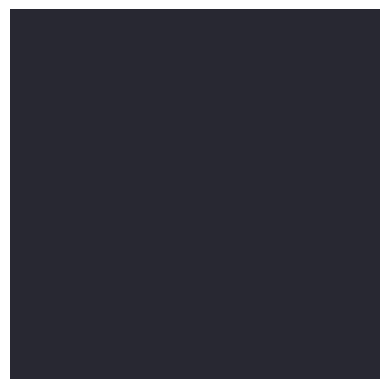

In [237]:
show_hsv_color(lower_bound)

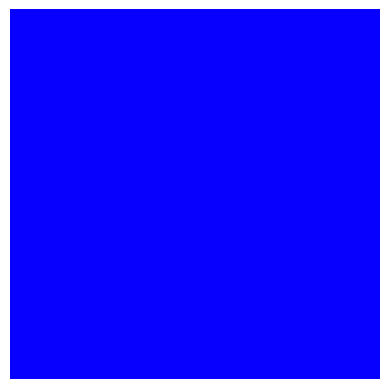

In [238]:
show_hsv_color(upper_bound)

In [239]:
mask = cv2.inRange(hsv_img, lower_bound, upper_bound)

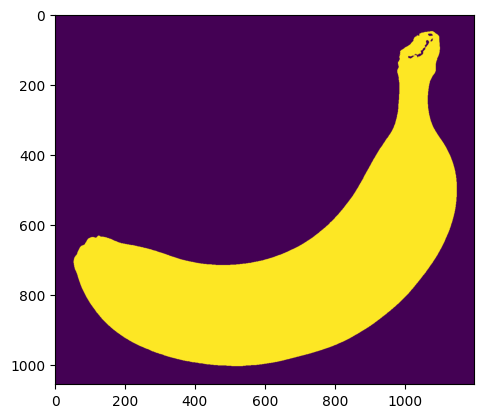

In [240]:
plt.imshow(mask)

### Operacje morfologiczne
Zamknięcie - usunięcie dziur + wygładzenie maski

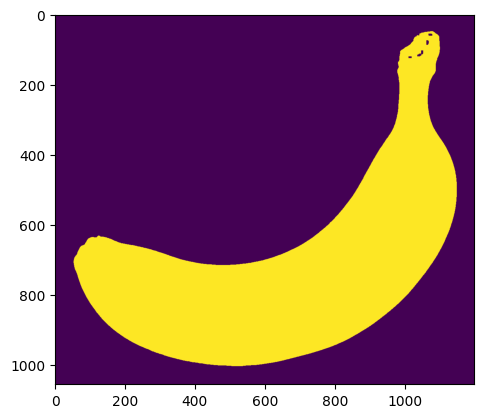

In [241]:
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(mask)

### Znalezienie największego konturu

In [242]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

In [243]:
# Stworzenie maski tylko dla największego konturu
object_mask = np.zeros_like(mask)
# -1 - indeks konturu - wszystkie z listy rysujemy
# 255 - kolor
# -1 grubośc lini - kontur wypełniony
cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1057, 1200), dtype=uint8)

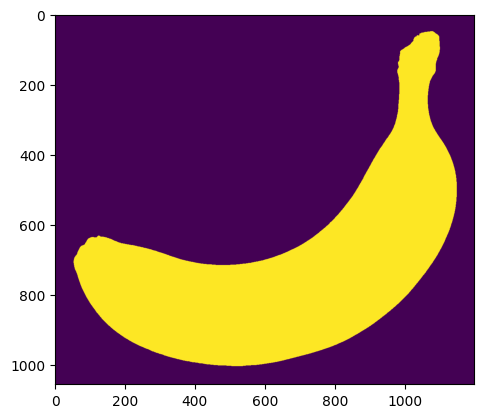

In [244]:
plt.imshow(object_mask)

### Nałożenie maski na owoc

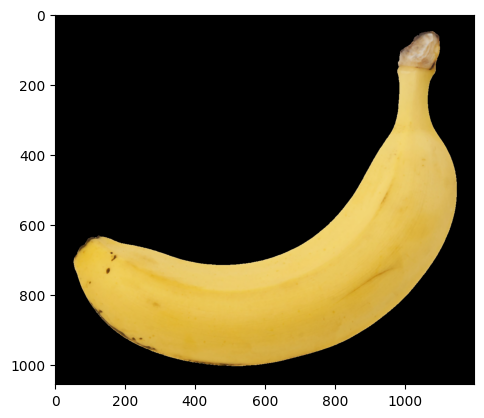

In [245]:
fruit_only = cv2.bitwise_and(blurred_img, blurred_img, mask=object_mask)
plt.imshow(BGR2RGB(fruit_only))

## Ekstrakcja cech

Cechy:
- średnie H
- średnie S
- średnie V
- odchylenie standardowe H
- odchylenie standardowe S
- odchylenie standardowe V
- współczynnik proporcji owocu
- eccentricity
- solidity
- convexity

### Ekstrakcja cech kolorów

In [198]:
hsv_img = cv2.cvtColor(fruit_only, cv2.COLOR_BGR2HSV)
h_channel = hsv_img[:, :, 0][object_mask == 255]
s_channel = hsv_img[:, :, 1][object_mask == 255]
v_channel = hsv_img[:, :, 2][object_mask == 255]

In [199]:
color_features = []

In [200]:
# Średnia
color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
# Odchylenie standardowe
color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

In [201]:
color_features

[np.float64(22.218270588516862),
 np.float64(159.56444008328745),
 np.float64(225.8503724268509),
 np.float64(1.236394576697297),
 np.float64(22.97654990251432),
 np.float64(15.856265382854076)]

### Aspect ratio

In [246]:
x, y, w, h = cv2.boundingRect(largest_contour)
aspect_ratio = w / h if h != 0 else 0
aspect_ratio

1.1442006269592477

### Eccentricity, Solidity

In [203]:
from skimage.measure import label, regionprops
# eccentricity
labeled_img = label(object_mask)
region = regionprops(labeled_img)[0]
eccentricity = region.eccentricity

# solidity
solidity = region.solidity

### Convexity

In [204]:
perimeter = cv2.arcLength(largest_contour, True)
convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
convexity = convex_hull_perimeter / perimeter

## Analiza zbioru

### Ramka

In [ ]:
import pandas as pd
column_labels = [
    'Class', 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]


### Funkcja wykonująca powyższą segmentację oraz ekstrahująca cechy z obrazu

In [206]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops

def extract_features(df_features, image_path, fruit):
  image = cv2.imread(image_path)
  if image is None:
    print("Failed to load image:", image_path)
    return

  # Odszumianie - filtr medianowy
  blurred_img = cv2.medianBlur(image, 5)

  # konwersja na HSV
  hsv_image = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)

  # maska
  lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
  upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność
  mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

  # Operacje morfologiczne - zamknięcie
  kernel = np.ones((5,5), np.uint8)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

  # znalezienie kontur
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  largest_contour = max(contours, key=cv2.contourArea)

  # Stworzenie maski tylko dla największego konturu
  object_mask = np.zeros_like(mask)
  cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)
  
  # zamaskowanie obrazu
  fruit_only = cv2.bitwise_and(blurred_img, blurred_img, mask=object_mask)
  hsv_image = cv2.cvtColor(fruit_only, cv2.COLOR_BGR2HSV)

  h_channel = hsv_image[:, :, 0]
  s_channel = hsv_image[:, :, 1]
  v_channel = hsv_image[:, :, 2]
  
  color_features = []

  # Średnia
  color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
  # Odchylenie standardowe
  color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

  # aspect ratio
  x, y, w, h = cv2.boundingRect(largest_contour)
  aspect_ratio = w / h if h != 0 else 0

  # eccentricity
  labeled_img = label(object_mask)
  region = regionprops(labeled_img)[0]
  eccentricity = region.eccentricity

  # solidity
  solidity = region.solidity

  # convexity
  perimeter = cv2.arcLength(largest_contour, True)
  convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
  convexity = convex_hull_perimeter / perimeter

  # Wektor cech
  feature_vector = np.array([fruit] + color_features + [aspect_ratio, eccentricity, solidity, convexity])

  df_features.loc[len(df_features)] = feature_vector

### Rozpatrywane klasy

In [207]:
fruits = ["apple", "banana", "pineapple"]

### Zbiór treningowy

In [210]:
df_train = pd.DataFrame(columns=column_labels)
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [ ]:
import os

dirpath = path + '/train'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_train, dirpath + '/' + fruit + '/' + filename, fruit)

In [212]:
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,4.545751388888889,50.728633333333335,43.00078888888889,15.166944773251437,78.94257677696987,67.96280036976017,1.0598885793871866,0.3035709575673296,0.9900985808193932,0.9017659072892173
2,apple,28.63712449799197,60.662955823293174,70.3066827309237,63.74565776285501,83.9971303273569,92.64228913874707,0.917098445595855,0.24272234677867183,0.9559078036500944,0.894251034019385
3,apple,55.11663541666667,112.59449583333334,111.37671875,45.64022038742705,64.9880178676871,50.66700596443473,1.5,0.7446844304347648,0.947715237217035,0.5407026911505509
4,apple,25.040821397569445,80.01944878472223,53.752367621527775,59.91586597295283,109.46884298276089,74.14852284091609,1.0491573033707866,0.5471763292246117,0.8921280778568825,0.6859696444447613
...,...,...,...,...,...,...,...,...,...,...,...
237,pineapple,6.578227163461539,61.04520783253205,37.56498798076923,13.13538437268847,87.28367376291374,59.69190161411471,0.588495575221239,0.7756224625595302,0.8597771338694729,0.5598688366963397
238,pineapple,18.08968608583225,80.47936332594591,87.9405570017091,15.844442985875137,72.66108080500713,77.31715073408368,1.5,0.7716479500405193,0.752741626036064,0.2711994939618817
239,pineapple,10.795980092592593,71.61474583333333,65.25665555555555,13.739601133341074,81.59945304978075,77.64460738327926,0.7357449417535254,0.6251668187056559,0.6903964552602762,0.41357081825543024
240,pineapple,11.118292647559171,38.700738582789675,55.41799205783885,19.523908955424144,61.7650835708954,85.19399104605888,0.4050867441468755,0.9452102807121476,0.7224509039417144,0.35502840547560455


### Zbiór testowy

In [213]:
df_test = pd.DataFrame(columns=column_labels)
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [214]:
dirpath = path + '/test'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_test, dirpath + '/' + fruit + '/' + filename, fruit)

In [215]:
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,24.12055328409176,59.969641235314604,61.723556119442826,57.838209608398834,83.27317683524781,83.80233443606686,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
2,apple,44.173747829861114,56.18214409722222,54.55312174479167,74.45165367742163,94.08688254812715,88.61069222016313,0.9226190476190477,0.6866873300843928,0.8715786989386182,0.6224610675467126
3,apple,46.9709405,43.523292,44.8135085,77.98752965728218,72.45564286846624,74.06006609111574,1.835575485799701,0.8815539484269911,0.8267072201292641,0.5495078477094937
4,apple,70.92785703943778,89.77043671565916,131.28755431063394,49.03185653021426,65.57189442520006,92.55618911401176,1.5,0.7279757426728309,0.7352330164973497,0.3354555128169366
5,apple,26.166629490150637,95.8314006373117,93.95147740440325,48.00942159877753,116.33209664129421,113.10218460983997,1.0868055555555556,0.36538429235225567,0.9154067296396405,0.9057693082805955
6,apple,94.62235625,120.29033489583334,102.66145104166667,88.46057404991078,98.84562304802589,92.14360770478224,0.9577015163607342,0.39229176598931875,0.9637515631099437,0.8336846286074336
7,apple,6.512612383327233,166.17280151903367,100.02938409361273,9.290888445591397,104.54200824168953,76.53814504094812,1.499267935578331,0.8091520527301259,0.7395437751647145,0.49291583795020877
8,apple,54.748760236105916,110.17793053996758,117.54776780147151,61.911092272266536,69.84261719832328,84.86965879010968,1.4666666666666666,0.6416363631842545,0.8476097543725488,0.4713801842733973
9,apple,12.236221788194445,118.01075086805555,111.9316796875,20.295905669380545,69.47598065127998,69.9483680821237,1.7777777777777777,0.8218613034021802,0.9024266115147643,0.6333851203034429


#### Normalizacja

W celu dalszego wyliczenia korelacji, dane rzutowane są na typ numeryczny (domyślnie string).

In [220]:
numeric_labels = [ 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]

for label in numeric_labels:
  df_train[label] = pd.to_numeric(df_train[label], errors='coerce')
  df_test[label] = pd.to_numeric(df_test[label], errors='coerce')

In [222]:
# odrzucenie kolumny 'Class'
X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

### Wizualizacja rozkładu cech

#### Cechy związane z kolorem

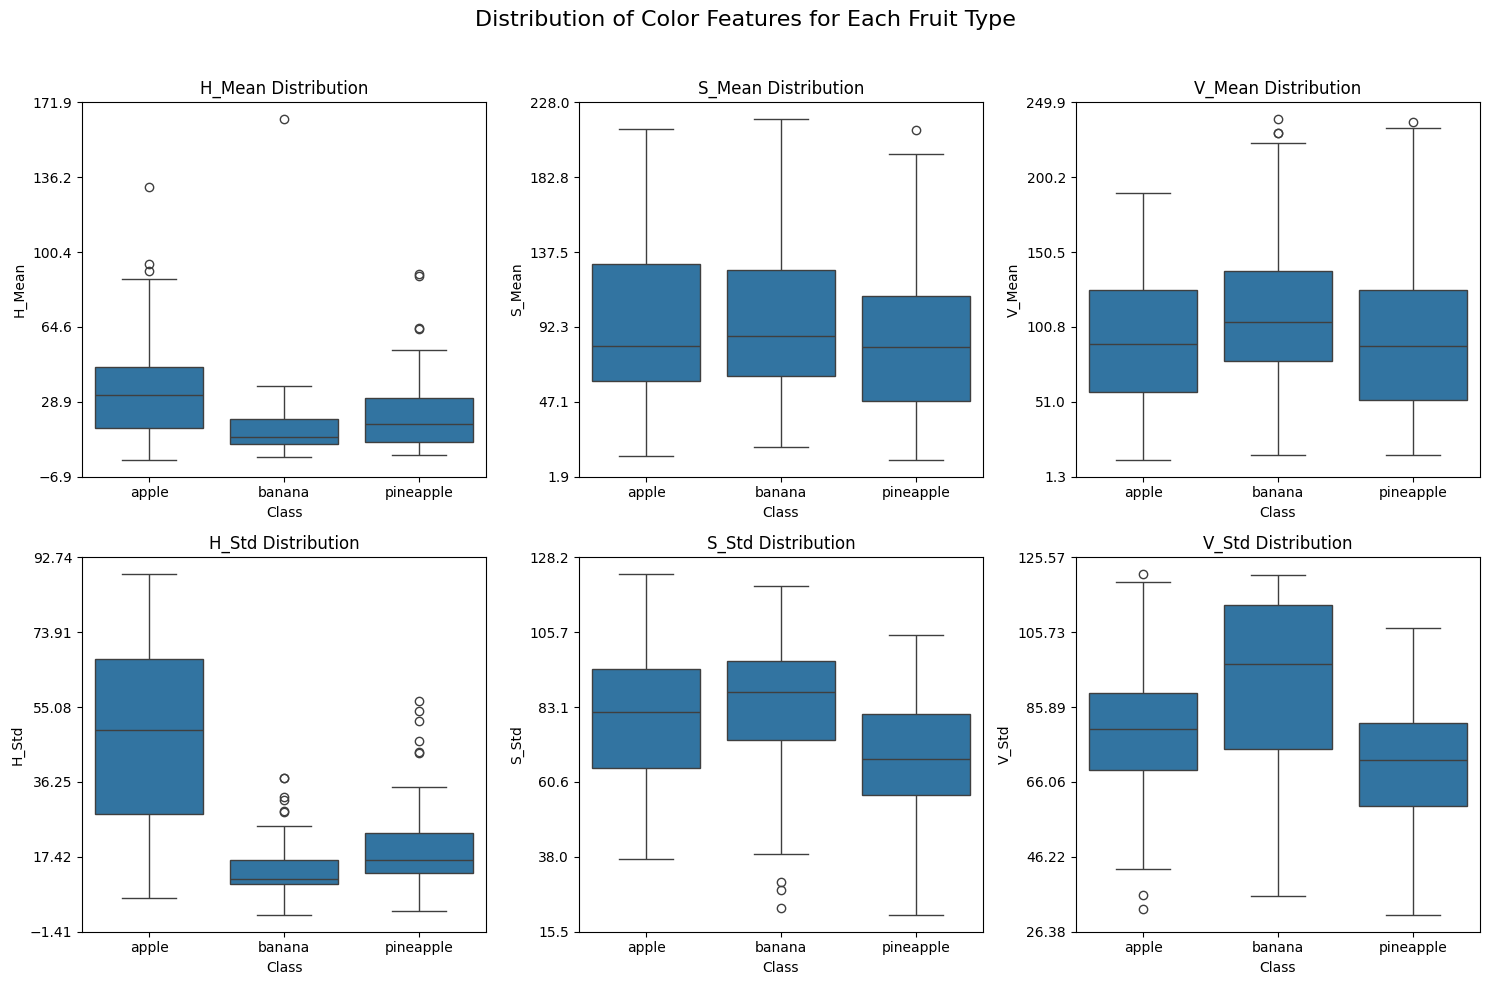

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

color_features = ['H_Mean', 'S_Mean', 'V_Mean', 'H_Std', 'S_Std', 'V_Std']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Color Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(color_features, 1):
    ax = plt.subplot(2, 3, i)
    
    sns.boxplot(x='Class', y=feature, data=df_train)
    plt.title(f'{feature} Distribution')
    
    # Force sorted y-ticks
    ymin, ymax = ax.get_ylim()
    num_ticks = 6
    ticks = np.linspace(ymin, ymax, num_ticks)
    ax.set_yticks(ticks)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Cechy związane ze kształtem

<Figure size 1500x500 with 0 Axes>

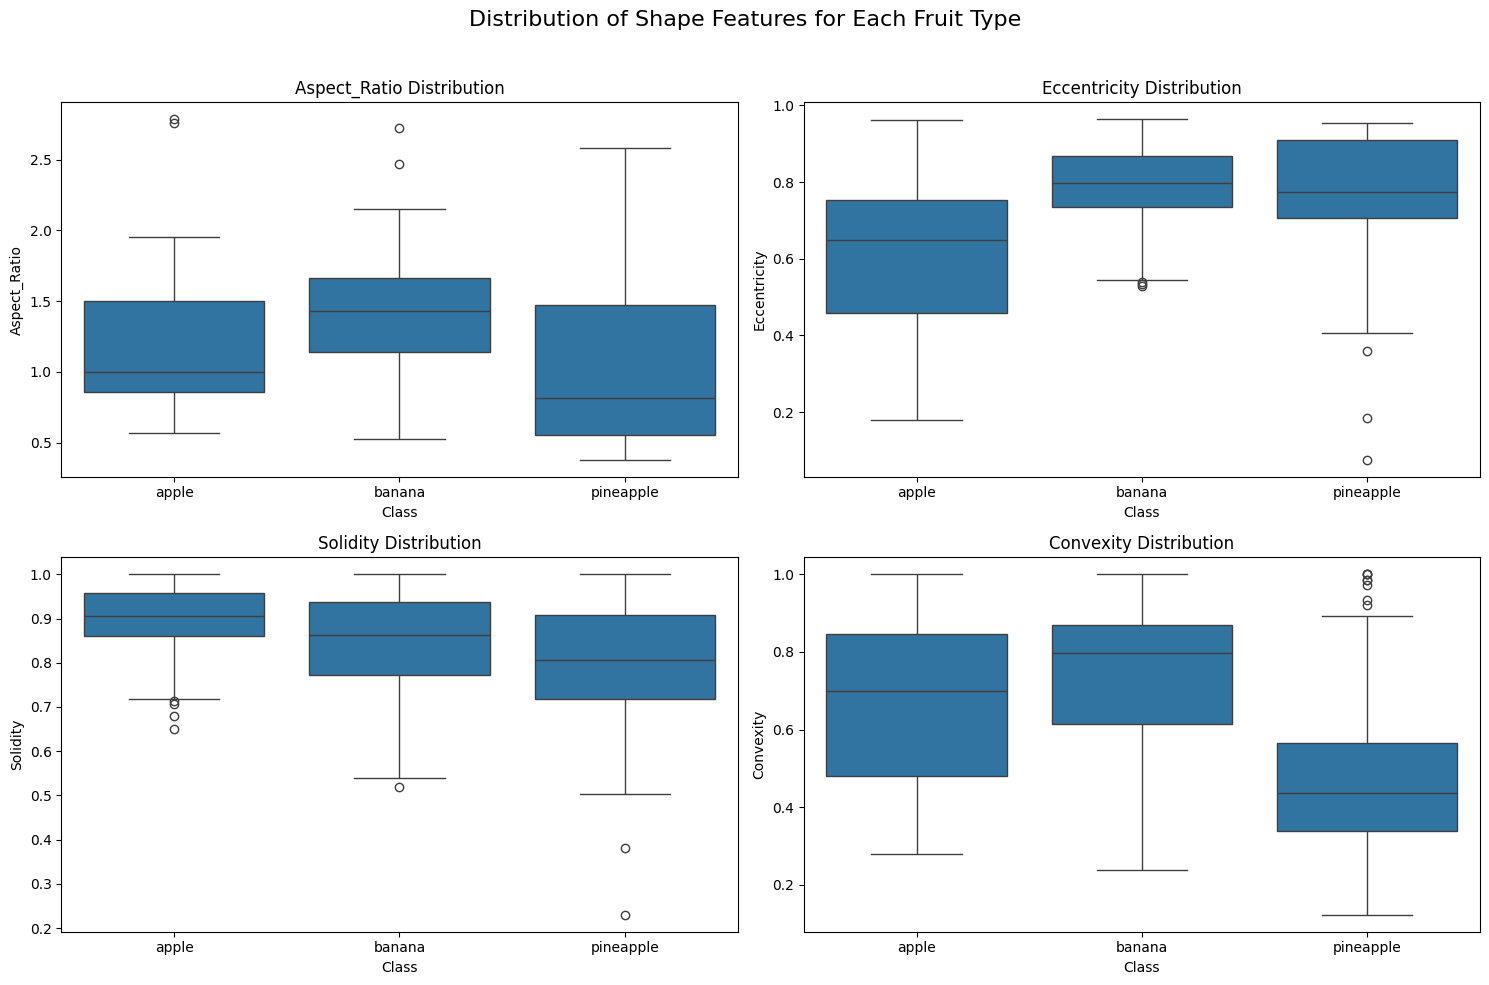

In [264]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

shape_features = ['Aspect_Ratio', 'Eccentricity', 'Solidity', 'Convexity']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(shape_features, 1):
  ax = plt.subplot(2, 2, i)
  
  sns.boxplot(x='Class', y=feature, data=df_train)
  plt.title(f'{feature} Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Macierz korelacji

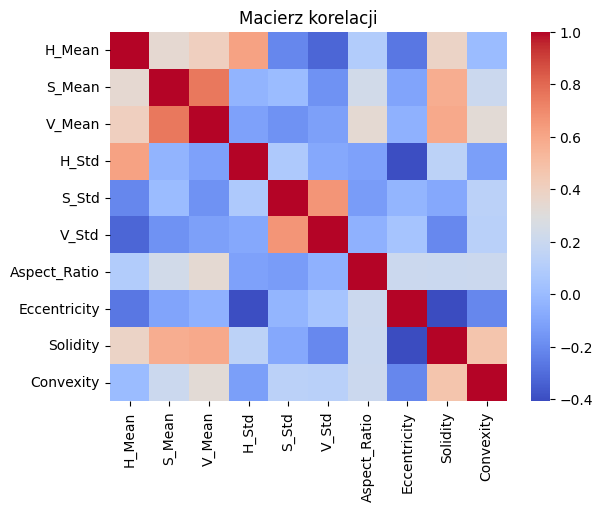

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = X_train.corr()
plt.figure()
sns.heatmap(correlation, cmap="coolwarm", annot=False)
plt.title("Macierz korelacji")
plt.show()

## Klasyfikacja

### Dobranie klasyfikatora
Na podstawie empirycznego testu, dobrano najlepszy klasyfikator - Drzewo Decyzyjne.

In [256]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# List of classifiers to try
classifiers = {
  'Random Forest': RandomForestClassifier(random_state=42),
  'SVM': SVC(random_state=42),
  'KNN': KNeighborsClassifier(),
  'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000),
  'Naive Bayes': GaussianNB(),
  'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
  clf.fit(X_train, y_train)
  accuracy = clf.score(X_test, y_test)
  results[name] = accuracy
  print(f'{name} Accuracy: {accuracy:.4f}')

# Find the best classifier
best_classifier_name = max(results, key=results.get)
print(f'\nBest classifier: {best_classifier_name} with accuracy {results[best_classifier_name]:.4f}')

Random Forest Accuracy: 0.8966
SVM Accuracy: 0.8621
KNN Accuracy: 0.8966
Logistic Regression Accuracy: 0.8276
Naive Bayes Accuracy: 0.8621
Decision Tree Accuracy: 0.9310

Best classifier: Decision Tree with accuracy 0.9310


### Confusion matrix

In [259]:
dtc = classifiers[best_classifier_name]
y_pred = dtc.predict(X_test)

Dokładność dtc: 0.931


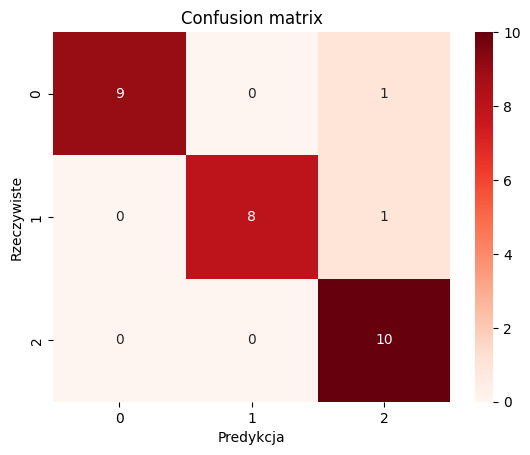

In [260]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Dokładność dtc: {dtc.score(X_test,y_test):.4}')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion matrix")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

### Feature ranking - najważniejsze cechy

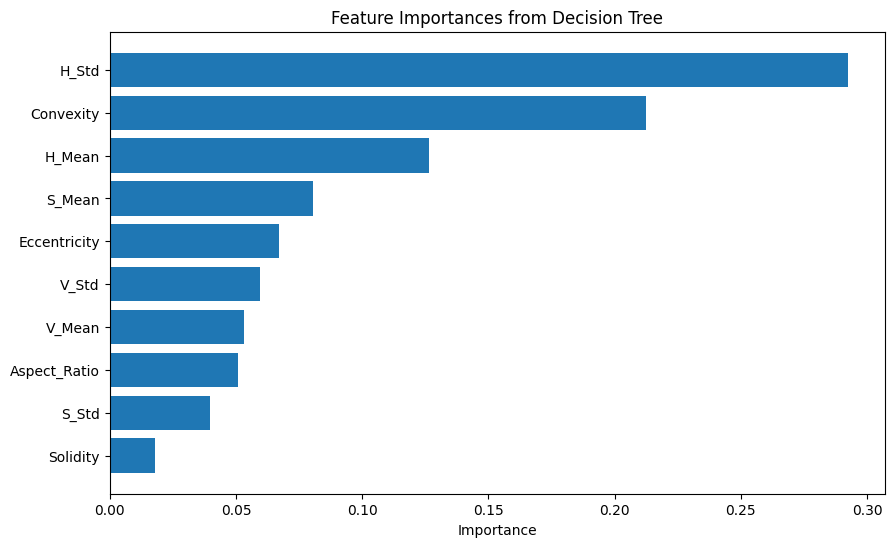

Top features by importance:
H_Std: 0.2923
Convexity: 0.2125
H_Mean: 0.1266
S_Mean: 0.0804
Eccentricity: 0.0670
V_Std: 0.0594
V_Mean: 0.0531
Aspect_Ratio: 0.0509
S_Std: 0.0399
Solidity: 0.0180


In [261]:
import matplotlib.pyplot as plt

# Get feature importances from the decision tree
feature_importances = dtc.feature_importances_
features = X_train.columns

# Sort features by importance
sorted_idx = feature_importances.argsort()

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Importance')
plt.title('Feature Importances from Decision Tree')
plt.show()

# Print top features
print("Top features by importance:")
for idx in sorted_idx[::-1]:
    print(f"{features[idx]}: {feature_importances[idx]:.4f}")